# Analyze the uploaded simulation results

This notebook parses the original headerless CSV files, audits completeness, and creates manuscript-facing tables and figures. The raw files under `data/` are never modified. Run the notebook from top to bottom.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'analysis').is_dir():
            return candidate.resolve()
    raise FileNotFoundError('Run this notebook from within the sensFDP directory.')

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from analysis.simulation_analysis import (
    bound_cdf, bound_summary, load_all_results, plot_bound_distributions,
    plot_runtime_diagnostic, plot_screening, runtime_summary,
    screening_summary, selection_summary, write_tables,
)

FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
pd.set_option('display.max_columns', 30)
PROJECT_ROOT

PosixPath('/Users/mengqilin/Downloads/sensFDP')

## 1. Parse and audit every file

A warning is retained whenever seeds are missing or duplicated, a record is malformed, or a legacy result needs further validation. No row is silently repaired or deduplicated.

In [2]:
results = load_all_results(PROJECT_ROOT)
results.audit

,experiment,file,records,valid_records,distinct_seeds,expected_seeds,missing_seeds,extra_seeds,duplicate_keys,missing_record_keys,unexpected_record_keys,malformed_records,status,note
0,subset selection,I500_setting0.csv,1000,1000,100,100,0,0,0,0,0,0,complete,
1,subset selection,I500_setting1.csv,1000,1000,100,100,0,0,0,0,0,0,complete,
2,subset selection,I500_setting2.csv,1000,1000,100,100,0,0,0,0,0,0,complete,
3,subset selection,I500_setting3.csv,1000,1000,100,100,0,0,0,0,0,0,complete,
4,subset selection,I500_setting4.csv,1000,1000,100,100,0,0,0,0,0,0,complete,
5,subset selection,I500_setting5.csv,1000,1000,100,100,0,0,0,0,0,0,complete,
6,subset selection,I500_setting6.csv,1000,1000,100,100,0,0,0,0,0,0,complete,
7,subset selection,I500_setting7.csv,1000,1000,100,100,0,0,0,0,0,0,complete,
8,subset selection,I500_setting8.csv,1000,1000,100,100,0,0,0,0,0,0,complete,
9,screening,Gamma_1.25.csv,99,99,99,100,1,0,0,0,0,0,warning,missing seeds: 60


In [3]:
results.audit.loc[results.audit['status'] == 'warning', ['experiment', 'file', 'note']]

,experiment,file,note
9,screening,Gamma_1.25.csv,missing seeds: 60
14,exact versus naive,rho0.2_I500_Gammalist1_1.25_1.5_1.75_nsim10.csv,missing seeds: 54; missing record keys: 10
15,runtime,closed_testing_equi_K10_I500.csv,"missing seeds: 47 (8,30,132,178,186,217,268,28..."
16,runtime,closed_testing_equi_K20_I500.csv,"missing seeds: 394 (0,1,2,3,4,5,6,7,8,9,10,11,..."


## 2. Subset-selection table

The manuscript configurations are settings 6, 0, and 3, corresponding to effect-outcome correlations -0.2, 0, and 0.2. Sensitivity values were stored on a 0.01 grid, so tied maximizing subsets occur often. To avoid dependence on subset enumeration order, the sensitivity selector below averages uniformly over all tied maximizers.

In [4]:
selection, selection_ties = selection_summary(
    results.selection_runs, results.selection_candidates
)
sensitivity_method = next(method for method in selection['method'].unique() if method != 'Naive selector')
selection_table = (
    selection.pivot(
        index='effect_correlation', columns='method', values='probability_success'
    )
    .reset_index()
    .sort_values('effect_correlation')
)[['effect_correlation', 'Naive selector', sensitivity_method]]
selection_table.round(3)

method,effect_correlation,Naive selector,"$\Gamma^*(\mathcal{R},1)$ selector"
0,-0.2,0.829,0.905
1,0.0,0.810,0.893
2,0.2,0.781,0.851


In [5]:
selection_ties[['effect_correlation', 'tied_replicates', 'tie_probability', 'maximum_number_of_maximizers']]

,effect_correlation,tied_replicates,tie_probability,maximum_number_of_maximizers
0,-0.2,123,0.123,5
1,0.0,160,0.160,6
2,0.2,205,0.205,5


The corrected success probabilities are 0.829 versus 0.905 at correlation -0.2, 0.810 versus 0.893 at correlation 0, and 0.781 versus 0.851 at correlation 0.2 (naive versus sensitivity selector). The sensitivity values are expected success probabilities under uniform tie-breaking, not one arbitrary realized tie rule.

## 3. Screening performance

The left panel is the probability that at least one outcome requires integer programming. The right panel is the average fraction of outcomes requiring it. Each stored row averages ten datasets for one seed. The Gamma=1.25 file is missing seed 60, so its curves use 990 rather than 1,000 datasets. At Gamma=1.5, both rates are nonmonotone over the available sample sizes; these data do not support a blanket finite-sample claim that the rates decrease with the number of pairs.

In [6]:
screening = screening_summary(results.screening)
screening[['gamma', 'pairs', 'probability_any_ip_call', 'average_fraction_called', 'datasets']].round(4)

,gamma,pairs,probability_any_ip_call,average_fraction_called,datasets
0,1.25,500,0.8485,0.1606,990
1,1.25,1000,0.6010,0.0806,990
2,1.25,2000,0.0424,0.0042,990
3,1.25,5000,0.0000,0.0000,990
4,1.25,10000,0.0000,0.0000,990
5,1.50,500,0.4730,0.0602,1000
6,1.50,1000,0.6390,0.0933,1000
7,1.50,2000,0.8270,0.1468,1000
8,1.50,5000,0.8210,0.1421,1000
9,1.50,10000,0.3140,0.0366,1000


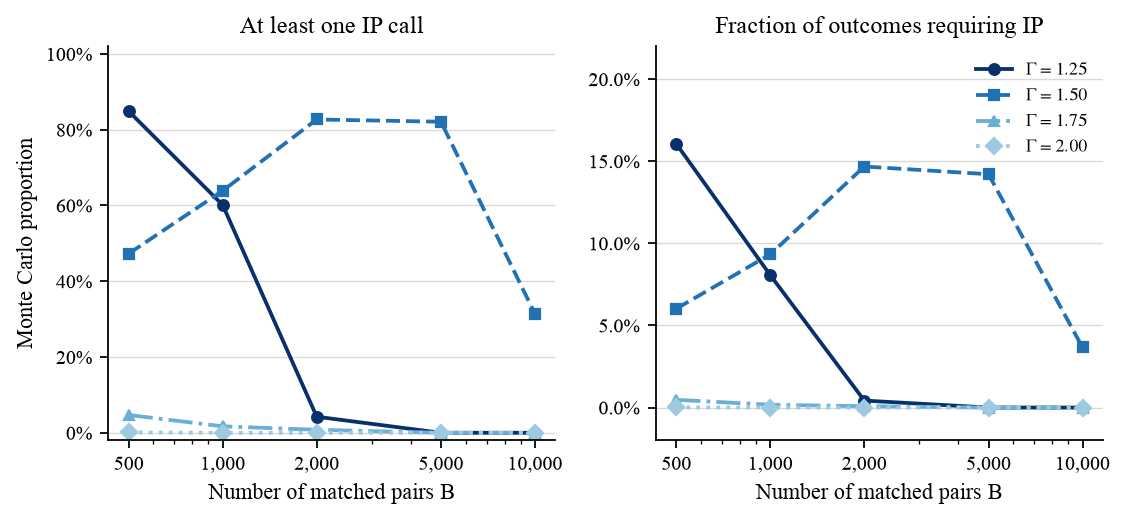

In [7]:
screening_figure = plot_screening(screening, FIGURE_DIR)
plt.show()

## 4. Exact versus naive FDP bounds

The curves show empirical CDFs of the FDP upper bound. A curve farther up and to the left is preferable. At correlation 0 and sensitivity parameter 1.5, the probability of a nonvacuous bound is 0.571 for the exact method and 0.221 for the naive method. The correlation-0.2 curves use 990 datasets because seed 54 is absent.

In [8]:
bounds = bound_summary(results.bounds)
bounds[['rho', 'gamma', 'datasets', 'exact_probability_at_most_0.75', 'naive_probability_at_most_0.75', 'probability_strict_improvement']].round(3)

,rho,gamma,datasets,exact_probability_at_most_0.75,naive_probability_at_most_0.75,probability_strict_improvement
0,0.0,1.00,1000,1.000,1.000,0.000
1,0.0,1.25,1000,0.972,0.893,0.231
2,0.0,1.50,1000,0.571,0.221,0.360
3,0.0,1.75,1000,0.097,0.013,0.084
4,0.2,1.00,990,1.000,1.000,0.000
5,0.2,1.25,990,0.922,0.857,0.164
6,0.2,1.50,990,0.364,0.215,0.160
7,0.2,1.75,990,0.031,0.012,0.019


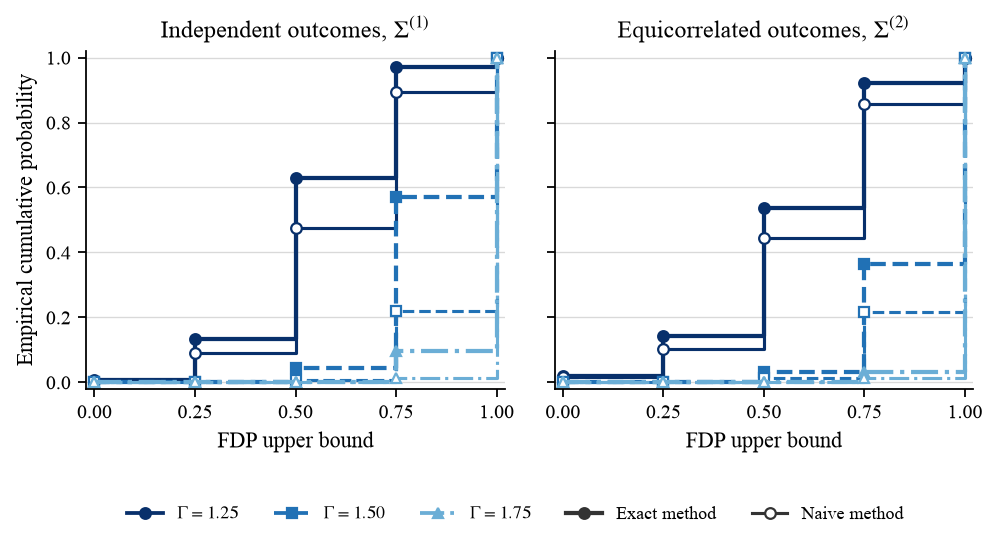

In [3]:
cdf = bound_cdf(results.bounds)
bound_figure = plot_bound_distributions(cdf, FIGURE_DIR)
plt.show()

## 5. Runtime results: diagnostic only

These files are not suitable for a final manuscript figure. The K=10 file has missing seeds and two conflicting records for seed 84; the K=20 file is incomplete and ends in a truncated row. Because rows were appended as cluster jobs finished, averages from either incomplete file may be completion-time biased. More importantly, the two stored rejection fractions disagree on many paired setting-record cells. Their grid strongly suggests one simulation per stored record, but `nsims` was not saved. The plot is generated only to diagnose the legacy output and is labeled accordingly.

In [5]:
runtime, runtime_quality = runtime_summary(results.runtime)
runtime_records = results.runtime[['K', 'seed', 'record']].drop_duplicates()
runtime_duplicate_seeds = (
    runtime_records.groupby(['K', 'seed'], as_index=False).size().query('size > 1')
)
runtime_quality

,K,records,distinct_seeds,setting_record_cells,rejection_fraction_mismatches,mismatch_probability
0,10,955,954,11460,312,0.027225
1,20,606,606,7272,1057,0.145352


In [6]:
runtime_records

,K,seed,record
0,10,0,21
1,10,1,81
2,10,2,2
3,10,3,157
4,10,4,167
...,...,...,...
12061,20,926,555
12062,20,936,602
12063,20,953,588
12064,20,971,583


In [10]:
runtime_duplicate_seeds

,K,seed,size
82,10,84,2


In [11]:
results.runtime_malformed

,file,record,seed,error
0,closed_testing_equi_K20_I500.csv,607,336,"SyntaxError: '[' was never closed (<unknown>, ..."


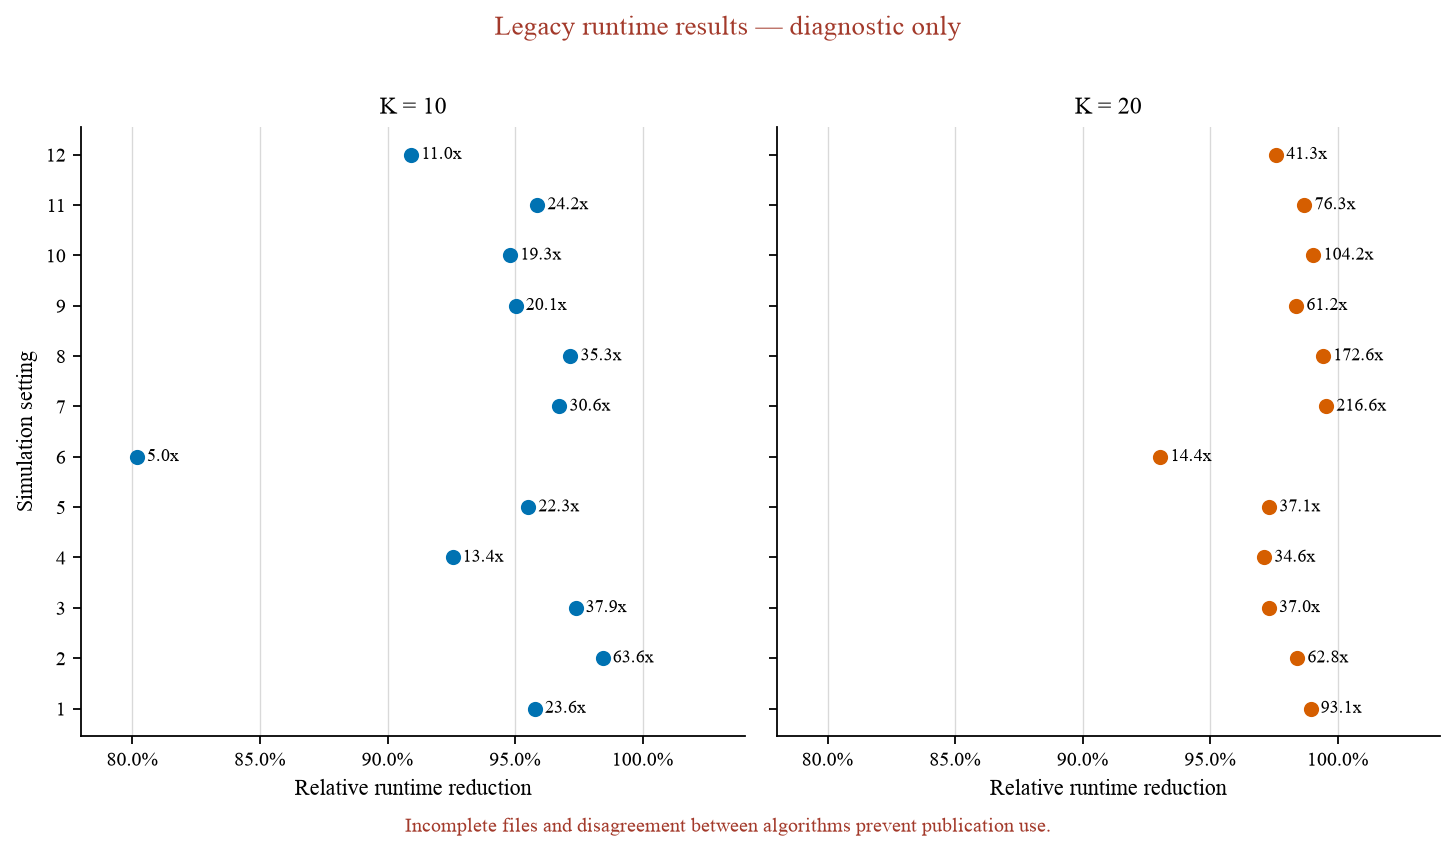

In [12]:
runtime_figure = plot_runtime_diagnostic(runtime, FIGURE_DIR)
plt.show()

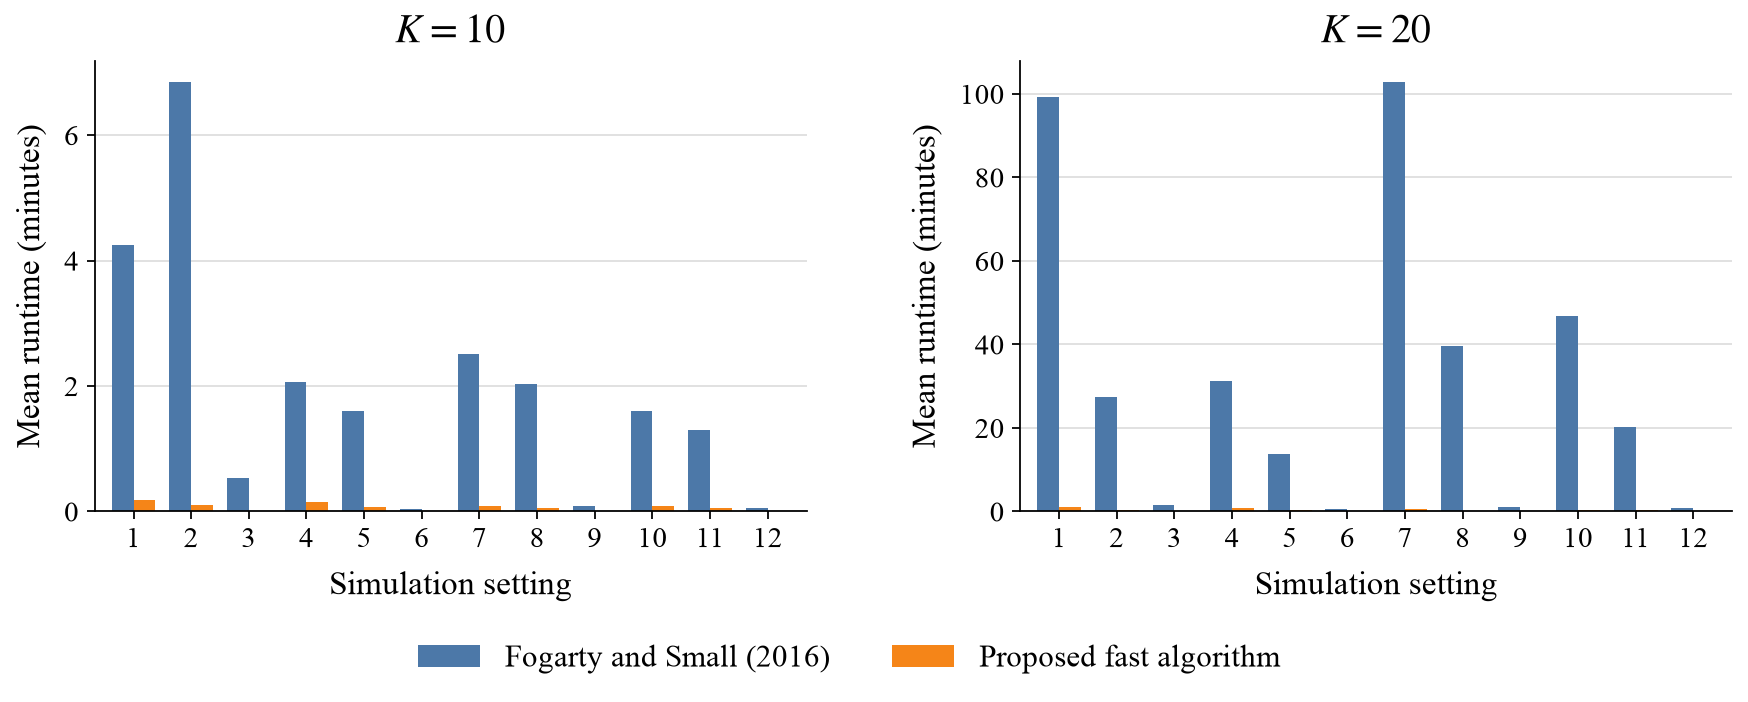

In [9]:
def plot_runtime_by_setting(runtime_summary, directory=None):
    """Plot side-by-side mean-runtime panels, with two bars per setting."""
    import numpy as np

    required = {
        'K', 'setting', 'enumerative_minutes', 'proposed_minutes'
    }
    missing = required.difference(runtime_summary.columns)
    if missing:
        raise ValueError(f'Missing required columns: {sorted(missing)}')

    frame = runtime_summary.sort_values(['K', 'setting']).copy()
    k_values = sorted(frame['K'].unique())

    # Force all K panels into one horizontal row.
    figure, axes = plt.subplots(
        nrows=1,
        ncols=len(k_values),
        figsize=(11.5, 4.4),
        sharex=False,
        sharey=False,
        squeeze=False,
    )
    axes = axes.ravel()

    bar_width = 0.38

    for axis, k in zip(axes, k_values):
        panel = frame.loc[frame['K'] == k].sort_values('setting')
        positions = np.arange(panel.shape[0])

        axis.bar(
            positions - bar_width / 2,
            panel['enumerative_minutes'],
            width=bar_width,
            color='#4C78A8',
            label='Fogarty and Small (2016)',
        )
        axis.bar(
            positions + bar_width / 2,
            panel['proposed_minutes'],
            width=bar_width,
            color='#F58518',
            label='Proposed fast algorithm',
        )

        axis.set_title(rf'$K={k}$', fontsize=18, pad=8)
        axis.set_xlabel('Simulation setting', fontsize=15, labelpad=8)
        axis.set_ylabel('Mean runtime (minutes)', fontsize=15, labelpad=8)

        axis.set_xticks(positions)
        axis.set_xticklabels(
            panel['setting'].astype(int),
            fontsize=13,
        )
        axis.tick_params(axis='y', labelsize=13)

        axis.set_axisbelow(True)
        axis.grid(
            axis='y',
            color='#D9D9D9',
            linewidth=0.7,
        )
        axis.margins(x=0.025)

    handles, labels = axes[0].get_legend_handles_labels()
    figure.legend(
        handles,
        labels,
        loc='lower center',
        ncol=2,
        frameon=False,
        fontsize=14,
        bbox_to_anchor=(0.5, -0.02),
    )

    figure.subplots_adjust(
        left=0.09,
        right=0.98,
        top=0.89,
        bottom=0.25,
        wspace=0.30,
    )

    if directory is not None:
        directory = Path(directory)
        directory.mkdir(parents=True, exist_ok=True)

        figure.savefig(
            directory / 'runtime_by_setting.pdf',
            bbox_inches='tight',
        )

    return figure


runtime_by_setting_figure = plot_runtime_by_setting(runtime, FIGURE_DIR)
plt.show()

## 6. Export tables

The following cell writes tidy CSV summaries, a LaTeX subset-selection table, and all audit diagnostics. Figures have already been saved in both PDF and PNG formats.

In [ ]:
write_tables(
    TABLE_DIR, audit=results.audit, selection=selection,
    selection_ties=selection_ties, screening=screening, bounds=bounds,
    runtime=runtime, runtime_quality=runtime_quality,
    runtime_malformed=results.runtime_malformed,
)
sorted(str(path.relative_to(PROJECT_ROOT)) for path in (PROJECT_ROOT / 'outputs').glob('**/*') if path.is_file())